In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [2]:
# Load Dataset
netflix_df = pd.read_csv("netflix_titles.csv")


In [3]:
# Data Understanding
print(netflix_df.head())

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

In [4]:
print(netflix_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None


In [5]:
print(netflix_df.isnull().sum())

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [6]:
# Data Cleaning
# Fill missing director and cast values
netflix_df['director'] = netflix_df['director'].fillna('Unknown')
netflix_df['cast'] = netflix_df['cast'].fillna('Unknown')

In [7]:
# Fill missing country values
mode_country = netflix_df['country'].mode()[0]
netflix_df['country'] = netflix_df['country'].fillna(mode_country)

In [8]:
# Remove rows with missing critical values
netflix_df.dropna(
    subset=['date_added', 'rating', 'duration'],
    inplace=True
)

In [9]:
# Convert date_added to datetime
netflix_df['date_added'] = pd.to_datetime(
    netflix_df['date_added'],
    format='mixed'
)

In [10]:
# Create new features
netflix_df['year_added'] = netflix_df['date_added'].dt.year
netflix_df['month_added'] = netflix_df['date_added'].dt.month

print("\nMissing Values After Cleaning:")
print(netflix_df.isnull().sum())


Missing Values After Cleaning:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
year_added      0
month_added     0
dtype: int64


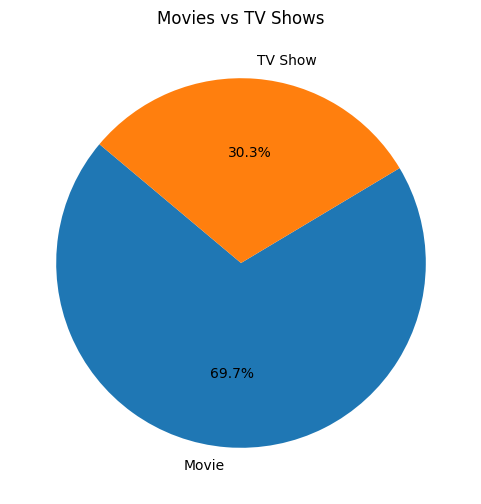

In [11]:
# Movies vs TV Shows
type_counts = netflix_df['type'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    type_counts,
    labels=type_counts.index,
    autopct='%1.1f%%',
    startangle=140
)
plt.title("Movies vs TV Shows")
plt.show()

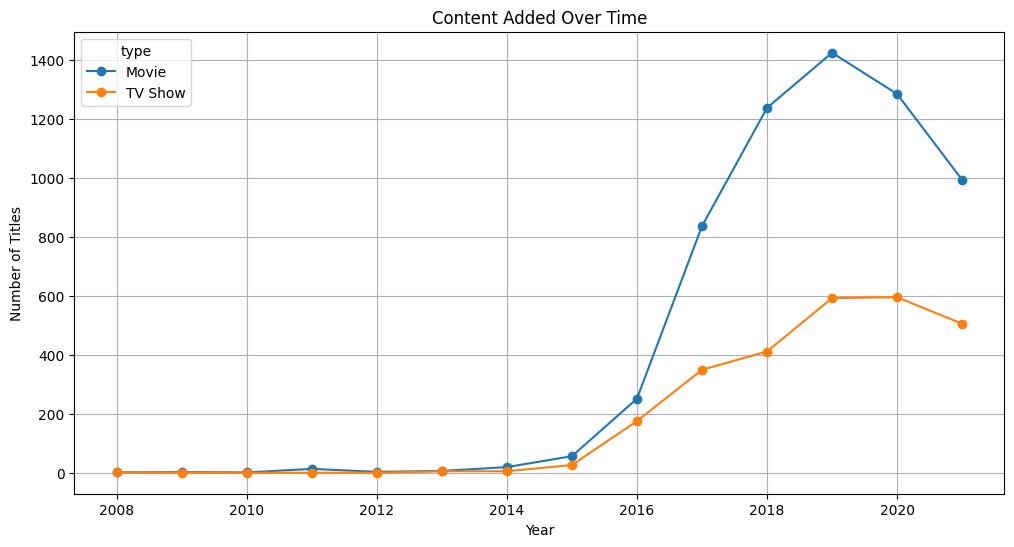

In [12]:
# Content Added Over Time
content_over_time = (
    netflix_df.groupby(['year_added', 'type'])
    .size()
    .unstack()
    .fillna(0)
)

content_over_time.plot(
    kind='line',
    marker='o',
    figsize=(12,6)
)

plt.title("Content Added Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.grid(True)
plt.show()


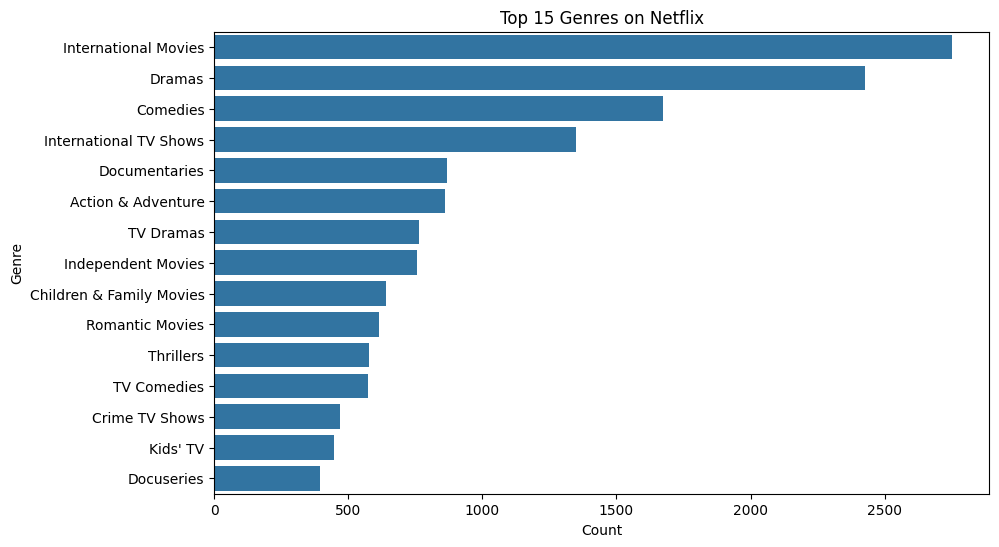

In [13]:
# Genre Analysis
genres = netflix_df.assign(
    genre=netflix_df['listed_in'].str.split(', ')
).explode('genre')

top_genres = genres['genre'].value_counts().head(15)

plt.figure(figsize=(10,6))
sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title("Top 15 Genres on Netflix")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.show()

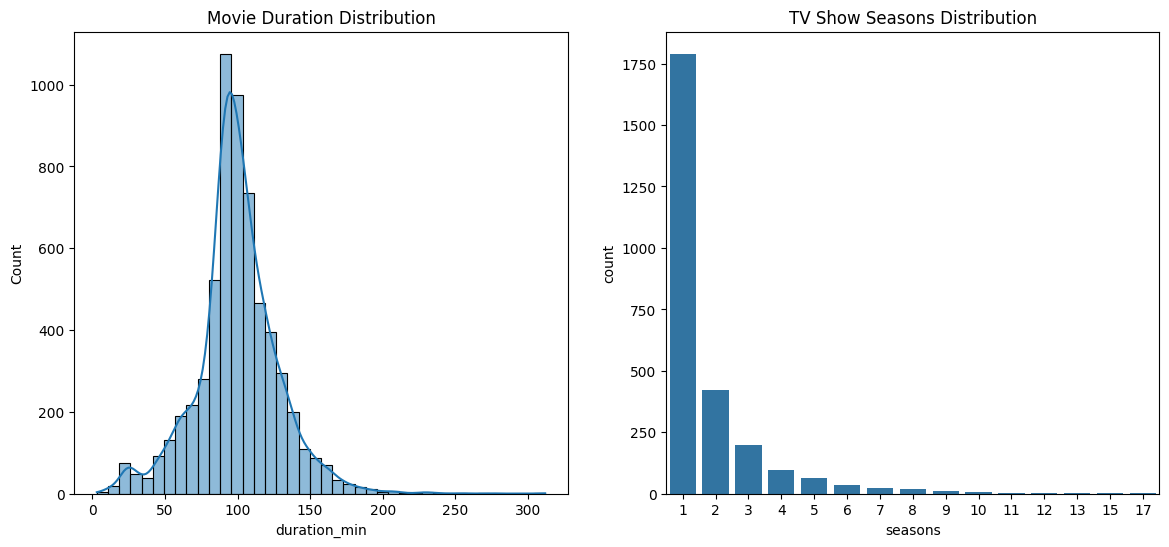

In [14]:
# Duration Analysis
movies_df = netflix_df[
    netflix_df['type'] == 'Movie'
].copy()

tv_shows_df = netflix_df[
    netflix_df['type'] == 'TV Show'
].copy()

movies_df['duration_min'] = (
    movies_df['duration']
    .str.replace(' min', '', regex=False)
    .astype(int)
)

tv_shows_df['seasons'] = (
    tv_shows_df['duration']
    .str.replace(' Seasons', '', regex=False)
    .str.replace(' Season', '', regex=False)
    .astype(int)
)

fig, axes = plt.subplots(1, 2, figsize=(14,6))

sns.histplot(
    movies_df['duration_min'],
    bins=40,
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Movie Duration Distribution")

sns.countplot(
    x='seasons',
    data=tv_shows_df,
    ax=axes[1]
)

axes[1].set_title("TV Show Seasons Distribution")
plt.show()

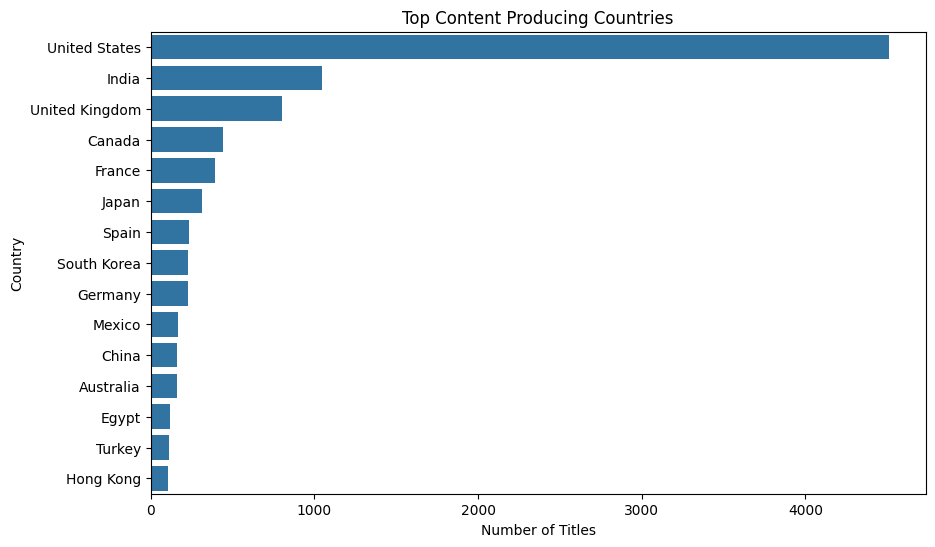

In [15]:
# Country Analysis
countries = netflix_df.assign(
    country=netflix_df['country'].str.split(', ')
).explode('country')

top_countries = (
    countries['country']
    .value_counts()
    .head(15)
)

plt.figure(figsize=(10,6))
sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)

plt.title("Top Content Producing Countries")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.show()


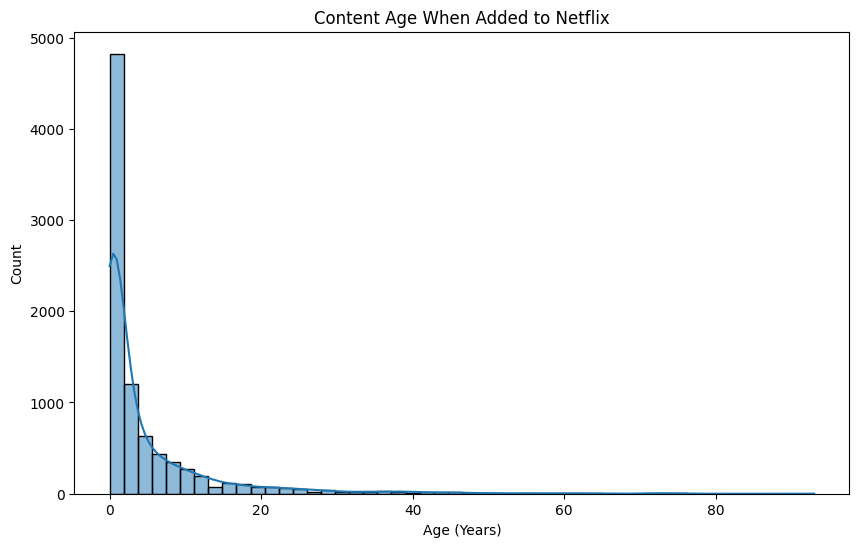

In [16]:
# Content Age Analysis
netflix_df['age_on_netflix'] = (
    netflix_df['year_added']
    - netflix_df['release_year']
)

content_age = netflix_df[
    netflix_df['age_on_netflix'] >= 0
]

plt.figure(figsize=(10,6))

sns.histplot(
    content_age['age_on_netflix'],
    bins=50,
    kde=True
)

plt.title("Content Age When Added to Netflix")
plt.xlabel("Age (Years)")
plt.show()


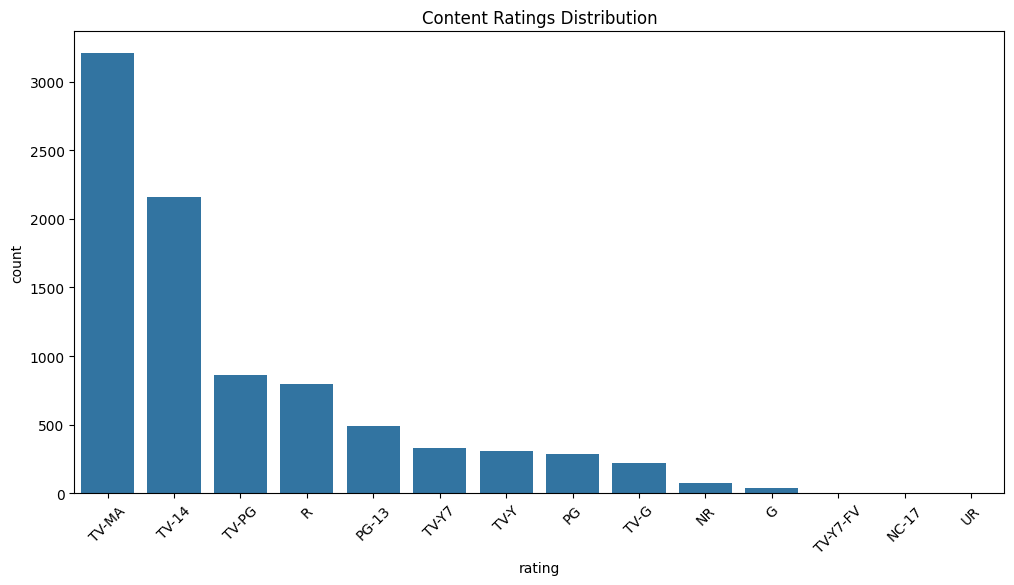

In [17]:
# Rating Analysis
plt.figure(figsize=(12,6))

sns.countplot(
    x='rating',
    data=netflix_df,
    order=netflix_df['rating'].value_counts().index
)

plt.title("Content Ratings Distribution")
plt.xticks(rotation=45)
plt.show()

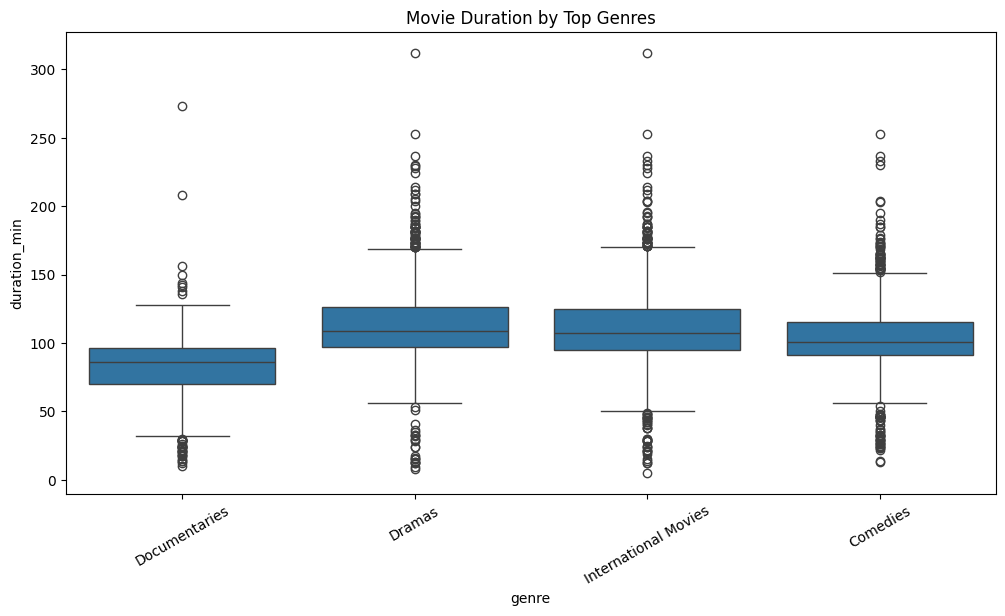

In [18]:
# Movie Duration by Genre
top_5_genres = (
    genres['genre']
    .value_counts()
    .index[:5]
)

genres_movies = genres[
    (genres['type'] == 'Movie') &
    (genres['genre'].isin(top_5_genres))
].copy()

genres_movies['duration_min'] = (
    genres_movies['duration']
    .str.replace(' min', '', regex=False)
    .astype(int)
)

plt.figure(figsize=(12,6))

sns.boxplot(
    data=genres_movies,
    x='genre',
    y='duration_min'
)

plt.title("Movie Duration by Top Genres")
plt.xticks(rotation=30)
plt.show()

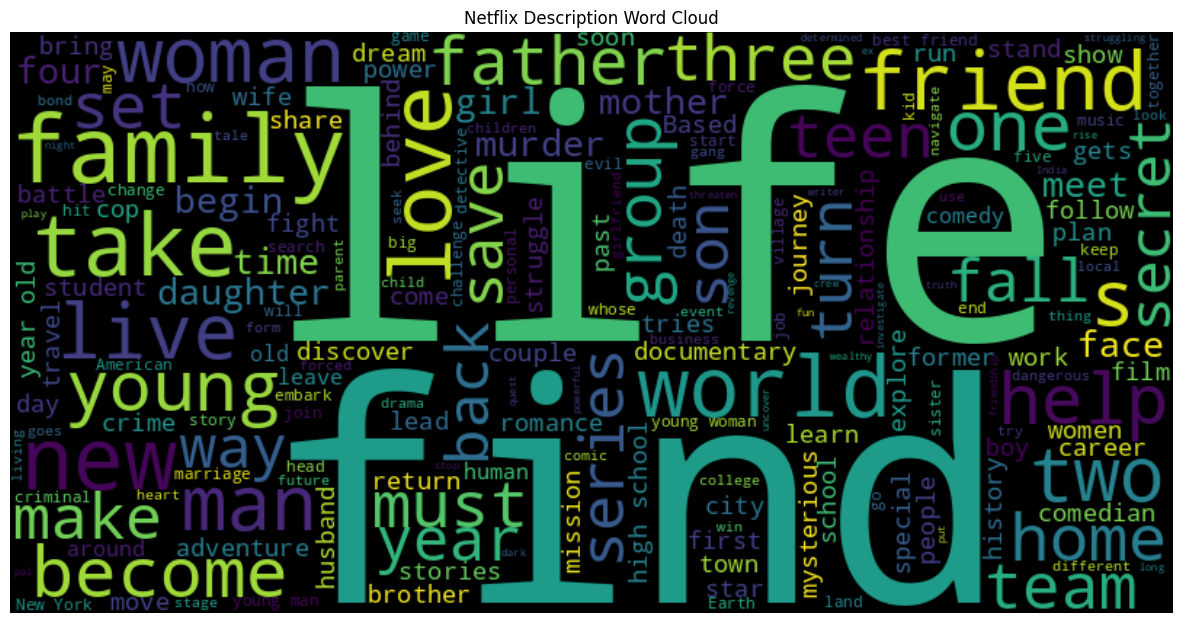

In [19]:
# Word Cloud
text = " ".join(
    netflix_df['description']
    .astype(str)
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='black'
).generate(text)

plt.figure(figsize=(15,8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Netflix Description Word Cloud")
plt.show()